In [1]:
print("hello")

hello


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


In [11]:
X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy", allow_pickle=True)
y_test = np.load("../data/processed/y_test.npy", allow_pickle=True)

In [12]:
X_train.shape, X_test.shape

((419, 6), (180, 6))

In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM (RBF Kernel)": SVC(kernel="rbf", probability=True),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

In [14]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="macro")
    rec = recall_score(y_test, y_pred, average="macro")
    f1 = f1_score(y_test, y_pred, average="macro")
    roc = roc_auc_score(y_test, y_prob, multi_class="ovr")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision (Macro)": prec,
        "Recall (Macro)": rec,
        "F1 Score (Macro)": f1,
        "ROC-AUC (Macro)": roc
    })

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),ROC-AUC (Macro)
0,Logistic Regression,0.655556,0.447990,0.519518,0.479195,0.730193
1,SVM (RBF Kernel),0.683333,0.469283,0.537439,0.497621,0.739824
2,Random Forest,0.638889,0.488047,0.508168,0.494650,0.784677


In [15]:
results_df.sort_values(by="F1 Score (Macro)", ascending=False)

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 Score (Macro),ROC-AUC (Macro)
1,SVM (RBF Kernel),0.683333,0.469283,0.537439,0.497621,0.739824
2,Random Forest,0.638889,0.488047,0.508168,0.494650,0.784677
0,Logistic Regression,0.655556,0.447990,0.519518,0.479195,0.730193


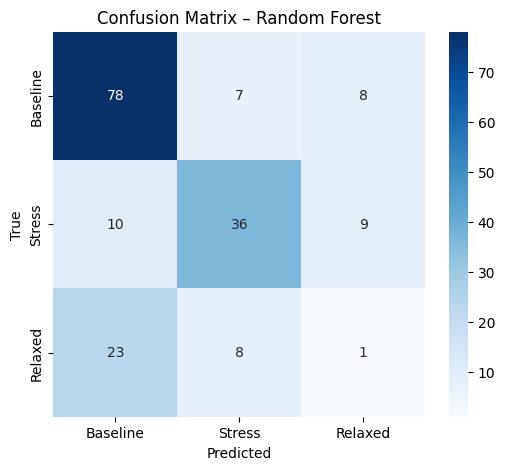

In [16]:
best_model = models["Random Forest"]
y_pred_rf = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Baseline", "Stress", "Relaxed"],
    yticklabels=["Baseline", "Stress", "Relaxed"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Random Forest")
plt.show()


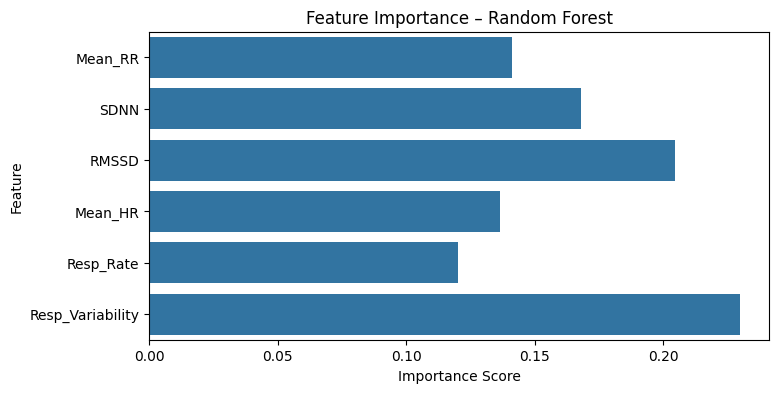

In [ ]:
feature_names = [
    "Mean_RR", "SDNN", "RMSSD", "Mean_HR",
    "Resp_Rate", "Resp_Variability"
]

importances = best_model.feature_importances_

plt.figure(figsize=(8,4))
sns.barplot(x=importances, y=feature_names)
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()
